In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from collections import Counter

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
def load_mnist():
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    return train_dataset, test_dataset

In [19]:
def create_dirichlet_clients(dataset, num_clients=10, alpha=0.5):
    labels = np.array(dataset.targets)
    num_classes = 10

    class_indices = [np.where(labels == i)[0] for i in range(num_classes)]

    client_indices = [[] for _ in range(num_clients)]

    for c in range(num_classes):
        if not class_indices[c].size: # Skip if this class has no samples in the dataset
            continue

        proportions = np.random.dirichlet([alpha]*num_clients)
        # Scale to the total number of samples for this class and convert to int
        proportions_int = (proportions * len(class_indices[c])).astype(int)

        # Distribute remaining samples due to truncation by astype(int)
        remaining_samples = len(class_indices[c]) - proportions_int.sum()

        if remaining_samples > 0:
            # Distribute remaining samples to clients with highest integer proportions
            add_indices = np.argsort(proportions_int)[::-1] # Indices in descending order
            for i in range(remaining_samples):
                proportions_int[add_indices[i % num_clients]] += 1

        # Now, proportions_int holds the count of samples from `class_indices[c]` for each client.
        # Split the actual indices. np.split handles empty splits correctly.
        split_points = np.cumsum(proportions_int)[:-1]
        splits = np.split(class_indices[c], split_points)

        # Add split indices to respective clients
        for i in range(num_clients):
            if i < len(splits): # Safety check
                client_indices[i].extend(splits[i].tolist())

    clients = []
    for i in range(num_clients):
        # Only create a DataLoader if the client has a non-empty set of indices
        if len(client_indices[i]) > 0:
            subset = Subset(dataset, client_indices[i])
            loader = DataLoader(subset, batch_size=32, shuffle=True)
            clients.append(loader)
        # Else, this client has no data and is effectively skipped.

    return clients

In [8]:
def compute_entropy(loader):
    labels = []
    for _, y in loader:
        labels.extend(y.numpy())

    counts = Counter(labels)
    total = len(labels)

    entropy = 0.0
    for c in counts:
        p = counts[c] / total
        entropy -= p * np.log(p + 1e-8)

    # normalize
    entropy /= np.log(10)

    return max(entropy, 1e-3)

In [9]:
def local_train(global_weights, dataloader, epochs=5, lr=0.01):
    model = MNISTNet().to(device)
    model.load_state_dict(global_weights)

    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()

    for _ in range(epochs):
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()

    return model.state_dict()

In [10]:
def aggregate_fedavg(models, sizes):
    total = sum(sizes)
    new_model = {}

    for k in models[0]:
        new_model[k] = sum(
            (sizes[i]/total) * models[i][k]
            for i in range(len(models))
        )

    return new_model

In [11]:
def aggregate_entropy(models, sizes, entropies):
    total = sum(sizes[i] * entropies[i] for i in range(len(models)))

    new_model = {}

    for k in models[0]:
        new_model[k] = sum(
            (sizes[i]*entropies[i]/total) * models[i][k]
            for i in range(len(models))
        )

    return new_model

In [12]:
def evaluate(model_weights, test_loader):
    model = MNISTNet().to(device)
    model.load_state_dict(model_weights)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [13]:
def run_federated_mnist(num_clients=10, rounds=10, alpha=0.3, client_creation_method='dirichlet'):
    train_dataset, test_dataset = load_mnist()

    if client_creation_method == 'dirichlet':
        clients = create_dirichlet_clients(train_dataset, num_clients, alpha)
    elif client_creation_method == 'random':
        clients = create_random_clients_full(train_dataset, num_clients)
    else:
        raise ValueError("Invalid client_creation_method. Choose 'dirichlet' or 'random'.")

    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    global_fedavg = MNISTNet().state_dict()
    global_entropy = MNISTNet().state_dict()

    fedavg_accuracies = []
    entropy_accuracies = []

    print(f"\n--- Running Federated MNIST with num_clients={num_clients}, rounds={rounds}, alpha={alpha} (method: {client_creation_method}) ---")

    for r in range(rounds):
        fedavg_models = []
        entropy_models = []
        sizes = []
        entropies = []

        for loader in clients:
            size = len(loader.dataset)

            # Move models to device before training
            model_fed = MNISTNet().to(device)
            model_fed.load_state_dict(global_fedavg)
            w_fed = local_train(model_fed.state_dict(), loader)

            model_ent = MNISTNet().to(device)
            model_ent.load_state_dict(global_entropy)
            w_ent = local_train(model_ent.state_dict(), loader)

            fedavg_models.append(w_fed)
            entropy_models.append(w_ent)

            sizes.append(size)
            entropies.append(compute_entropy(loader))

        # aggregate
        global_fedavg = aggregate_fedavg(fedavg_models, sizes)
        global_entropy = aggregate_entropy(entropy_models, sizes, entropies)

        # evaluate
        acc_fed = evaluate(global_fedavg, test_loader)
        acc_ent = evaluate(global_entropy, test_loader)

        fedavg_accuracies.append(acc_fed)
        entropy_accuracies.append(acc_ent)

        print(f"Round {r+1}: FedAvg={acc_fed:.4f}, Entropy-FL={acc_ent:.4f}")

    return fedavg_accuracies, entropy_accuracies

In [20]:
# --- Experiment Setup ---

experiment_params = [
    # Non-IID cases (low alpha)
    {"num_clients": 10, "rounds": 20, "alpha": 0.01, "client_creation_method": "dirichlet", "label": "Non-IID (Alpha=0.01)"},
    {"num_clients": 10, "rounds": 20, "alpha": 0.1, "client_creation_method": "dirichlet", "label": "Non-IID (Alpha=0.1)"},
    # IID cases (higher alpha)
    {"num_clients": 10, "rounds": 20, "alpha": 1.0, "client_creation_method": "dirichlet", "label": "IID (Alpha=1.0)"},
    {"num_clients": 10, "rounds": 20, "alpha": 100.0, "client_creation_method": "dirichlet", "label": "Highly IID (Alpha=100.0)"},
    # Random distribution
    {"num_clients": 10, "rounds": 20, "alpha": 0.0, "client_creation_method": "random", "label": "Random Distribution"} # alpha is ignored for random
]

results = {} # Clear previous partial results

for params in experiment_params:
    print(f"Running experiment: {params['label']}")
    fedavg_accs, entropy_accs = run_federated_mnist(
        num_clients=params["num_clients"],
        rounds=params["rounds"],
        alpha=params["alpha"],
        client_creation_method=params["client_creation_method"]
    )
    results[params["label"]] = {
        "fedavg": fedavg_accs,
        "entropy": entropy_accs
    }

print("Experiments complete!")

Running experiment: Non-IID (Alpha=0.01)

--- Running Federated MNIST with num_clients=10, rounds=20, alpha=0.01 (method: dirichlet) ---
Round 1: FedAvg=0.1826, Entropy-FL=0.1880
Round 2: FedAvg=0.1812, Entropy-FL=0.2354
Round 3: FedAvg=0.2229, Entropy-FL=0.2612
Round 4: FedAvg=0.2737, Entropy-FL=0.2746
Round 5: FedAvg=0.3276, Entropy-FL=0.2787
Round 6: FedAvg=0.3726, Entropy-FL=0.2959
Round 7: FedAvg=0.3987, Entropy-FL=0.3039
Round 8: FedAvg=0.4207, Entropy-FL=0.3110
Round 9: FedAvg=0.4357, Entropy-FL=0.3233
Round 10: FedAvg=0.4622, Entropy-FL=0.3201
Round 11: FedAvg=0.4843, Entropy-FL=0.3306
Round 12: FedAvg=0.5105, Entropy-FL=0.3393
Round 13: FedAvg=0.5282, Entropy-FL=0.3501
Round 14: FedAvg=0.5542, Entropy-FL=0.3525
Round 15: FedAvg=0.5705, Entropy-FL=0.3628
Round 16: FedAvg=0.5831, Entropy-FL=0.3706
Round 17: FedAvg=0.5931, Entropy-FL=0.3742
Round 18: FedAvg=0.6036, Entropy-FL=0.3809
Round 19: FedAvg=0.6197, Entropy-FL=0.3881
Round 20: FedAvg=0.6336, Entropy-FL=0.3971
Running expe

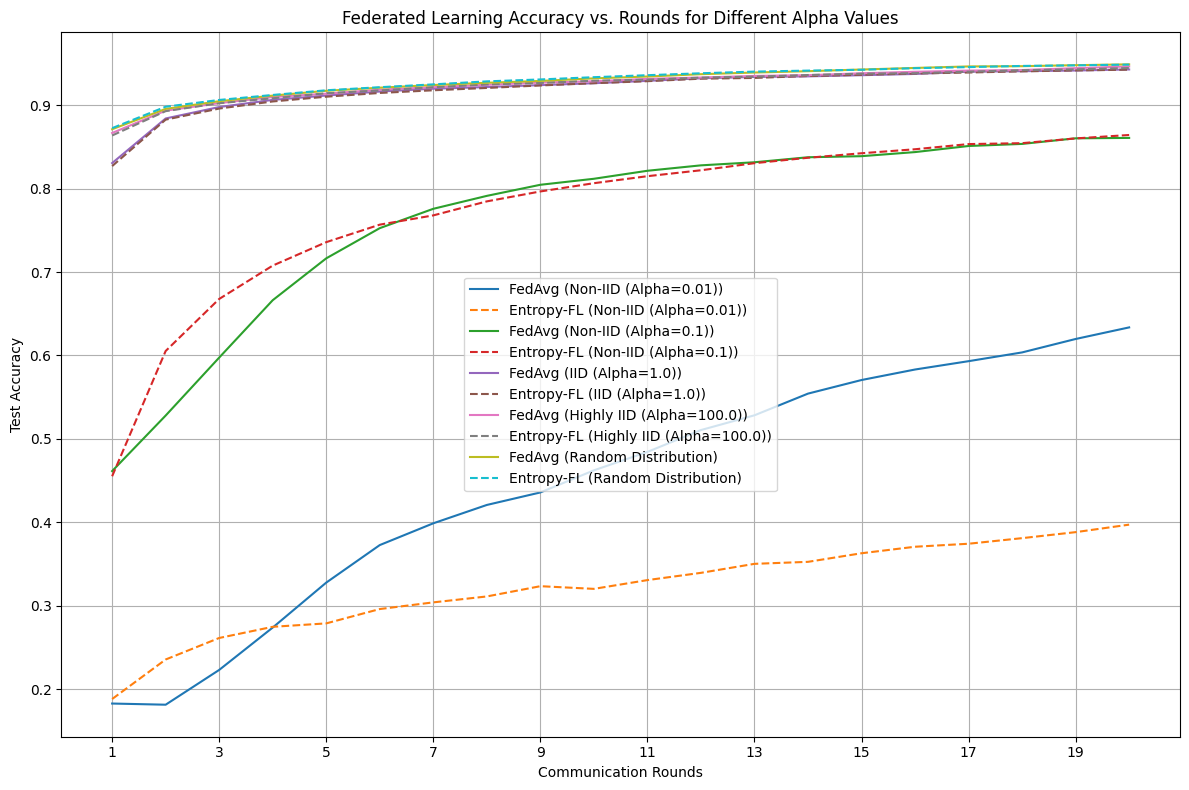

In [21]:
# --- Plotting Results ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for label, data in results.items():
    rounds = range(1, len(data["fedavg"]) + 1)
    plt.plot(rounds, data["fedavg"], label=f"FedAvg ({label})", linestyle='-')
    plt.plot(rounds, data["entropy"], label=f"Entropy-FL ({label})", linestyle='--')

plt.title("Federated Learning Accuracy vs. Rounds for Different Alpha Values")
plt.xlabel("Communication Rounds")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.xticks(range(1, max(len(v['fedavg']) for v in results.values()) + 1, 2))
plt.tight_layout()
plt.show()

In [ ]:
run_federated_mnist(num_clients=10, rounds=15, alpha=0.1)

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.60MB/s]


Round 1: FedAvg=0.5079, Entropy-FL=0.5538
Round 2: FedAvg=0.5658, Entropy-FL=0.5881
Round 3: FedAvg=0.5857, Entropy-FL=0.6053
Round 4: FedAvg=0.6140, Entropy-FL=0.6118
Round 5: FedAvg=0.6657, Entropy-FL=0.6201
Round 6: FedAvg=0.7113, Entropy-FL=0.6326
Round 7: FedAvg=0.7450, Entropy-FL=0.6431
Round 8: FedAvg=0.7783, Entropy-FL=0.6546
Round 9: FedAvg=0.7938, Entropy-FL=0.6692
Round 10: FedAvg=0.8117, Entropy-FL=0.6867
Round 11: FedAvg=0.8248, Entropy-FL=0.7049
Round 12: FedAvg=0.8348, Entropy-FL=0.7236
Round 13: FedAvg=0.8460, Entropy-FL=0.7461
Round 14: FedAvg=0.8564, Entropy-FL=0.7570
Round 15: FedAvg=0.8603, Entropy-FL=0.7720


In [ ]:
run_federated_mnist(10,30,0.5)

Round 1: FedAvg=0.6350, Entropy-FL=0.6636
Round 2: FedAvg=0.7588, Entropy-FL=0.7910
Round 3: FedAvg=0.8129, Entropy-FL=0.8310
Round 4: FedAvg=0.8397, Entropy-FL=0.8511
Round 5: FedAvg=0.8566, Entropy-FL=0.8678
Round 6: FedAvg=0.8701, Entropy-FL=0.8763
Round 7: FedAvg=0.8773, Entropy-FL=0.8810
Round 8: FedAvg=0.8810, Entropy-FL=0.8860
Round 9: FedAvg=0.8852, Entropy-FL=0.8898
Round 10: FedAvg=0.8879, Entropy-FL=0.8917
Round 11: FedAvg=0.8895, Entropy-FL=0.8941
Round 12: FedAvg=0.8928, Entropy-FL=0.8963
Round 13: FedAvg=0.8950, Entropy-FL=0.8967
Round 14: FedAvg=0.8972, Entropy-FL=0.8986
Round 15: FedAvg=0.8989, Entropy-FL=0.9002
Round 16: FedAvg=0.8999, Entropy-FL=0.9019
Round 17: FedAvg=0.9012, Entropy-FL=0.9035
Round 18: FedAvg=0.9044, Entropy-FL=0.9039
Round 19: FedAvg=0.9044, Entropy-FL=0.9049
Round 20: FedAvg=0.9058, Entropy-FL=0.9054
Round 21: FedAvg=0.9068, Entropy-FL=0.9064
Round 22: FedAvg=0.9072, Entropy-FL=0.9078
Round 23: FedAvg=0.9099, Entropy-FL=0.9090
Round 24: FedAvg=0.9

In [ ]:
def get_label_distribution(loader, num_classes=10):
    counts = np.zeros(num_classes)

    for _, y in loader:
        for label in y.numpy():
            counts[label] += 1

    probs = counts / counts.sum()

    # avoid zeros (important for KL)
    probs = np.clip(probs, 1e-8, 1.0)
    probs = probs / probs.sum()

    return probs

In [ ]:
def kl_divergence(p, q):
    return np.sum(p * np.log(p / q))

In [ ]:
def compute_global_distribution(client_distributions, sizes):
    total = sum(sizes)

    global_dist = sum(
        (sizes[i]/total) * client_distributions[i]
        for i in range(len(sizes))
    )

    global_dist = np.clip(global_dist, 1e-8, 1.0)
    global_dist = global_dist / global_dist.sum()

    return global_dist

In [ ]:
def aggregate_kl(models, sizes, client_distributions, tau=5.0):
    # global distribution
    global_dist = compute_global_distribution(client_distributions, sizes)

    # compute KL for each client
    kls = [
        kl_divergence(client_distributions[i], global_dist)
        for i in range(len(models))
    ]

    # convert to weights (softmax over -KL)
    weights = np.array([
        sizes[i] * np.exp(-tau * kls[i])
        for i in range(len(models))
    ])

    weights = weights / weights.sum()

    # aggregate
    new_model = {}

    for k in models[0]:
        new_model[k] = sum(
            weights[i] * models[i][k]
            for i in range(len(models))
        )

    return new_model, kls

In [ ]:
def run_federated_kl(num_clients=10, rounds=10, alpha=0.3):
    train_dataset, test_dataset = load_mnist()

    clients = create_dirichlet_clients(train_dataset, num_clients, alpha)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    global_kl = MNISTNet().state_dict()

    for r in range(rounds):
        local_models = []
        sizes = []
        distributions = []

        for loader in clients:
            size = len(loader.dataset)

            # train
            local_weights = local_train(global_kl, loader)

            # distribution
            dist = get_label_distribution(loader)

            local_models.append(local_weights)
            sizes.append(size)
            distributions.append(dist)

        # aggregate
        global_kl, kls = aggregate_kl(local_models, sizes, distributions)

        # evaluate
        acc = evaluate(global_kl, test_loader)

        print(f"[KL-FL] Round {r+1}: Acc={acc:.4f}, Avg KL={np.mean(kls):.4f}")

In [17]:
def create_random_clients_full(dataset, num_clients=10):
    total_samples = len(dataset)

    indices = np.random.permutation(total_samples)

    # random proportions
    proportions = np.random.dirichlet(np.ones(num_clients))
    sizes = (proportions * total_samples).astype(int)

    # fix rounding
    sizes[-1] = total_samples - sizes[:-1].sum()

    clients = []
    start = 0

    for size in sizes:
        subset_indices = indices[start:start+size]
        start += size

        subset = Subset(dataset, subset_indices)
        loader = DataLoader(subset, batch_size=32, shuffle=True)

        clients.append(loader)

    return clients

In [ ]:
run_federated_kl(num_clients=10, rounds=15, alpha=0.3)

[KL-FL] Round 1: Acc=0.4426, Avg KL=0.7479
[KL-FL] Round 2: Acc=0.5261, Avg KL=0.7479
[KL-FL] Round 3: Acc=0.5784, Avg KL=0.7479
[KL-FL] Round 4: Acc=0.6297, Avg KL=0.7479
[KL-FL] Round 5: Acc=0.6978, Avg KL=0.7479
[KL-FL] Round 6: Acc=0.7423, Avg KL=0.7479


KeyboardInterrupt: 

In [ ]:
clients = create_random_clients_full(train_dataset, num_clients=10)

NameError: name 'train_dataset' is not defined